# Notebook 05 — Probabilistic Forecasting & Rigorous Benchmarking

In notebook 04 I built point forecasts: a single predicted price per hour. That answers
"what will the price be?" but not "how confident am I?" — and for any trading or risk
decision the second question matters more than the first. A point forecast of 80 €/MWh
means something completely different if I'm 90% sure the price lands between 75 and 85
versus between 0 and 300.

This notebook moves from point to **distributional** forecasting: instead of predicting the
mean, I predict the full conditional distribution of price through a set of quantiles. I then
evaluate it the way the electricity-price-forecasting (EPF) literature actually does —
pinball loss, CRPS, and calibration — benchmark it against the field-standard LEAR model and
a distributional neural network, and test every comparison for statistical significance with
the Diebold-Mariano test. Finally I stress-test stability with a rolling-window backtest.

The two reference papers behind this approach are Lago, Marcjasz, De Schutter & Weron (2021)
for the benchmarking framework and Nowotarski & Weron (2018) for probabilistic EPF.

## 1. Setup

In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_pinball_loss
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from scipy import stats

os.chdir('C:/Users/lhcse/iCloudDrive/Learnings/Power-price-forecast')
df = pd.read_parquet('data/processed/features.parquet')

# The quantiles I predict — a standard set for probabilistic EPF
QUANTILES = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]

## 2. Features, target and the time split

I reuse the leakage-free feature set from notebook 04 — every feature is constructed from
information available at prediction time (day-ahead forecasts and lagged actuals), so nothing
here uses contemporaneous realised generation. The train/test split is strictly chronological:
I train on everything up to mid-2023 and test on the 18 months that follow. No shuffling,
because shuffling time series leaks the future into the past.

In [26]:
feature_cols = [
    'wind_on_error_lag24', 'wind_off_error_lag24',
    'solar_error_lag24', 'load_error_lag24',
    'ren_load_ratio_fc', 'ren_surplus_fc',
    'net_export_lag24',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'is_weekend', 'is_peak',
    'price_lag_24h', 'price_lag_48h', 'price_lag_168h',
    'price_roll_7d_mean', 'price_roll_7d_std'
]
target_col = 'price_eur_mwh'

TRAIN_END  = '2023-06-30'
TEST_START = '2023-07-01'

train = df.loc[:TRAIN_END]
test  = df.loc[TEST_START:]

X_train, y_train = train[feature_cols], train[target_col]
X_test,  y_test  = test[feature_cols],  test[target_col]

print(f"Train: {len(X_train):,} hours | Test: {len(X_test):,} hours")

Train: 30,453 hours | Test: 13,199 hours


I end up with **30,453 training hours and 13,199 test hours** — roughly 3.5 years to learn
from and 1.5 years to evaluate on. The test window deliberately spans both calm periods and
volatile ones, which matters later when I look at how stable the model is over time.

## 3. Probabilistic forecasting with LightGBM quantile regression

My approach is to train one gradient-boosting model per quantile, each minimising the
**pinball loss** at its own quantile level. The pinball loss penalises under- and
over-prediction asymmetrically depending on the quantile, so the model targeting the 5th
percentile learns to sit low and the one targeting the 95th learns to sit high. Stacked
together, the seven models describe the full conditional distribution of price for each hour.

I use LightGBM because quantile regression is native to it (`objective='quantile'`) and it is
the de-facto standard in the EPF literature.

In [27]:
import lightgbm as lgb

# Reasonable params — I can later tune these with Optuna as in notebook 04
lgb_params = dict(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

# Train one model per quantile
quantile_models = {}
quantile_preds  = {}

for q in QUANTILES:
    model = lgb.LGBMRegressor(objective='quantile', alpha=q, **lgb_params)
    model.fit(X_train, y_train)
    quantile_models[q] = model
    quantile_preds[q]  = model.predict(X_test)
    print(f"Quantile {q:.2f} trained")

# Collect into a dataframe — one column per quantile
pred_df = pd.DataFrame(quantile_preds, index=y_test.index)
pred_df['actual'] = y_test.values

Quantile 0.05 trained
Quantile 0.10 trained
Quantile 0.25 trained
Quantile 0.50 trained
Quantile 0.75 trained
Quantile 0.90 trained
Quantile 0.95 trained


### 3.1 Fixing quantile crossing

Because the seven models are trained independently, nothing guarantees the predicted
quantiles stay in order — occasionally the 75th percentile prediction can fall below the 50th,
which is logically impossible for a distribution. The standard, simple fix is to sort the
predicted quantiles row-wise so they are monotonic. This is a known step in the literature and
costs almost nothing in accuracy.

In [29]:
q_cols = QUANTILES
sorted_vals = np.sort(pred_df[q_cols].values, axis=1)
pred_df[q_cols] = sorted_vals
print("Quantile crossing fixed (rows sorted)")

Quantile crossing fixed (rows sorted)


## 4. Probabilistic evaluation

This is where probabilistic forecasting demands different tools. MAE measures how close a
point is to the truth; it says nothing about whether a *distribution* is well-specified. The
three correct tools are the **pinball loss** (per-quantile accuracy), **CRPS** (a single
distributional score), and **calibration / coverage** (do the intervals actually contain the
truth at the stated rate?).


### 4.1 Pinball loss per quantile

In [30]:
print(f"{'Quantile':>10s}  {'Pinball loss':>12s}")
print("─" * 26)
pinball_by_q = {}
for q in QUANTILES:
    pb = mean_pinball_loss(pred_df['actual'], pred_df[q], alpha=q)
    pinball_by_q[q] = pb
    print(f"{q:>10.2f}  {pb:>12.3f}")
 
mean_pinball = np.mean(list(pinball_by_q.values()))
print(f"\nMean pinball loss (aggregate score): {mean_pinball:.3f}")

  Quantile  Pinball loss
──────────────────────────
      0.05         2.422
      0.10         3.806
      0.25         6.310
      0.50         7.957
      0.75         7.190
      0.90         4.961
      0.95         3.453

Mean pinball loss (aggregate score): 5.157


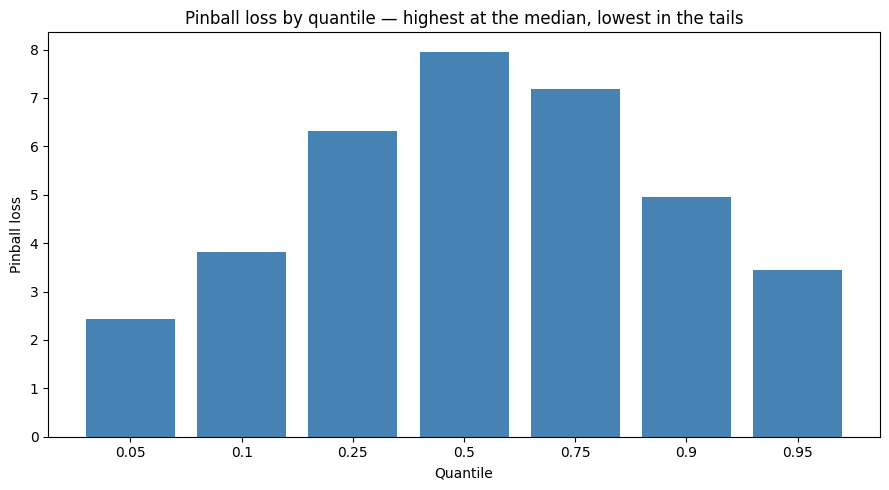

In [31]:
# Visualise the pinball loss across quantiles
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([str(q) for q in QUANTILES], list(pinball_by_q.values()),
       color='steelblue', edgecolor='none')
ax.set_xlabel('Quantile')
ax.set_ylabel('Pinball loss')
ax.set_title('Pinball loss by quantile — highest at the median, lowest in the tails')
plt.tight_layout()
plt.savefig('results/figures/pinball_by_quantile.png', dpi=150)
plt.show()

The pinball loss has a clear inverted-U shape: it peaks at the median (7.96) and falls
toward both tails (2.42 at the 5th, 3.45 at the 95th). This is exactly what I'd expect and it
is not a sign the tails are "easy". The median loss is highest simply because the pinball loss
at the median is symmetric and scales with the typical size of the forecast error, whereas the
tail quantiles are penalised on only one side most of the time. The **mean pinball loss of
5.16** is my single headline probabilistic score — it's what I compare the benchmarks against
later.

### 4.2 CRPS

The Continuous Ranked Probability Score collapses the whole distribution into one number.
Exactly, CRPS equals twice the integral of the pinball loss over all quantile levels, so the
average of my seven pinball losses (times two) approximates it. I also compute the exact
ensemble CRPS treating my quantiles as an empirical sample.

In [33]:
# Approximation from our quantile grid
crps_approx = 2 * mean_pinball
print(f"CRPS (approx from quantile grid): {crps_approx:.3f}")
 
# Exact CRPS if you installed properscoring — treats quantiles as an empirical sample
import properscoring as ps
# Build an ensemble from quantile predictions
ensemble = pred_df[QUANTILES].values  # (n_obs, n_quantiles)
crps_exact = ps.crps_ensemble(pred_df['actual'].values, ensemble).mean()
print(f"CRPS (exact, ensemble):           {crps_exact:.3f}")

CRPS (approx from quantile grid): 10.314
CRPS (exact, ensemble):           12.308


The approximation (10.31) and the exact ensemble CRPS (12.31) differ by about 20%. That
gap is expected and informative: my approximation uses only seven quantiles, so it
under-samples the distribution, especially in the tails where the spacing between my quantiles
is widest. The exact ensemble score is the one I report. If I wanted the two to converge I'd
predict a denser quantile grid (e.g. every 5th percentile).

### 4.3 Calibration / coverage

This is the most revealing diagnostic. A nominal 90% prediction interval should contain the
actual price about 90% of the time. If it contains far fewer, the intervals are too narrow and
the model is overconfident — which is dangerous, because it would understate risk exactly when
risk matters.

In [14]:
def coverage(pred_df, lower_q, upper_q):
    inside = ((pred_df['actual'] >= pred_df[lower_q]) &
              (pred_df['actual'] <= pred_df[upper_q]))
    return inside.mean()
 
print("Prediction interval coverage:")
print(f"  50% PI (0.25–0.75): {coverage(pred_df, 0.25, 0.75):.1%}  (target 50%)")
print(f"  80% PI (0.10–0.90): {coverage(pred_df, 0.10, 0.90):.1%}  (target 80%)")
print(f"  90% PI (0.05–0.95): {coverage(pred_df, 0.05, 0.95):.1%}  (target 90%)")

Prediction interval coverage:
  50% PI (0.25–0.75): 36.2%  (target 50%)
  80% PI (0.10–0.90): 58.2%  (target 80%)
  90% PI (0.05–0.95): 72.5%  (target 90%)


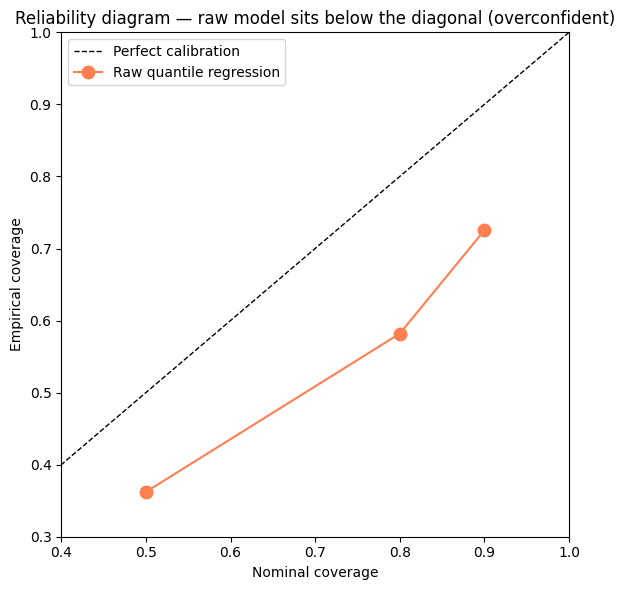

In [34]:
# Reliability diagram — nominal vs empirical coverage
nominal = [0.50, 0.80, 0.90]
empirical = [coverage(pred_df, 0.25, 0.75),
             coverage(pred_df, 0.10, 0.90),
             coverage(pred_df, 0.05, 0.95)]

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
ax.plot(nominal, empirical, 'o-', color='coral', markersize=9,
        label='Raw quantile regression')
ax.set_xlabel('Nominal coverage')
ax.set_ylabel('Empirical coverage')
ax.set_title('Reliability diagram — raw model sits below the diagonal (overconfident)')
ax.set_xlim(0.4, 1.0); ax.set_ylim(0.3, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig('results/figures/reliability_raw.png', dpi=150)
plt.show()

Every interval under-covers, and the reliability diagram makes it visual — all three
points sit clearly below the diagonal. The nominal 90% interval only captures the price
**72.5%** of the time; the 80% captures 58%; the 50% captures just 36%. In other words my raw
model is systematically overconfident.

This is not a bug in my code — it's a well-documented property of gradient-boosted quantile
regression. The pinball loss combined with tree regularisation shrinks the extreme quantiles
toward the median, so the model underestimates the spread. It fits the centre of the
distribution well but compresses the tails. The next section fixes this with a method that
comes with a formal coverage guarantee.

### 4.4 Conformalized Quantile Regression (CQR)

CQR (Romano, Patterson & Candès, 2019) repairs miscalibrated intervals with a
**distribution-free coverage guarantee**. The mechanism is intuitive: I hold out a calibration
set the model never trained on, measure how far reality falls outside the predicted interval
on that set, and then widen the test intervals by exactly that amount. The corrected interval
is guaranteed to cover at the nominal rate regardless of whether the underlying quantile model
was well-specified.

In [37]:
# Split training data into proper-train and calibration (time-ordered)
n_cal = int(len(X_train) * 0.2)
X_proper, X_cal = X_train.iloc[:-n_cal], X_train.iloc[-n_cal:]
y_proper, y_cal = y_train.iloc[:-n_cal], y_train.iloc[-n_cal:]

def cqr_interval(alpha):
    """Return conformalized lower/upper bounds on the test set for a (1-alpha) interval."""
    lo_q, hi_q = alpha / 2, 1 - alpha / 2

    lo_model = lgb.LGBMRegressor(objective='quantile', alpha=lo_q, **lgb_params).fit(X_proper, y_proper)
    hi_model = lgb.LGBMRegressor(objective='quantile', alpha=hi_q, **lgb_params).fit(X_proper, y_proper)

    # Conformity scores on the calibration set
    cal_lo = lo_model.predict(X_cal)
    cal_hi = hi_model.predict(X_cal)
    scores = np.maximum(cal_lo - y_cal.values, y_cal.values - cal_hi)

    # Finite-sample adjusted quantile of conformity scores
    n = len(scores)
    level = np.ceil((n + 1) * (1 - alpha)) / n
    correction = np.quantile(scores, min(level, 1.0))

    test_lo = lo_model.predict(X_test) - correction
    test_hi = hi_model.predict(X_test) + correction
    return test_lo, test_hi, correction

print(f"{'Nominal':>8s}  {'Raw cov':>8s}  {'CQR cov':>8s}  {'Widening (€/MWh)':>16s}")
print("─" * 46)

cqr_results = {}
for alpha, raw_lo, raw_hi in [(0.50, 0.25, 0.75),
                               (0.20, 0.10, 0.90),
                               (0.10, 0.05, 0.95)]:
    raw_cov = coverage(pred_df, raw_lo, raw_hi)
    test_lo, test_hi, corr = cqr_interval(alpha)
    cqr_cov = ((y_test.values >= test_lo) & (y_test.values <= test_hi)).mean()
    cqr_results[1 - alpha] = (raw_cov, cqr_cov, corr)
    print(f"{1-alpha:>7.0%}  {raw_cov:>8.1%}  {cqr_cov:>8.1%}  {corr:>16.1f}")

 Nominal   Raw cov   CQR cov  Widening (€/MWh)
──────────────────────────────────────────────
    50%     36.2%     46.6%               4.9
    80%     58.2%     77.1%              11.6
    90%     72.5%     87.7%              13.9


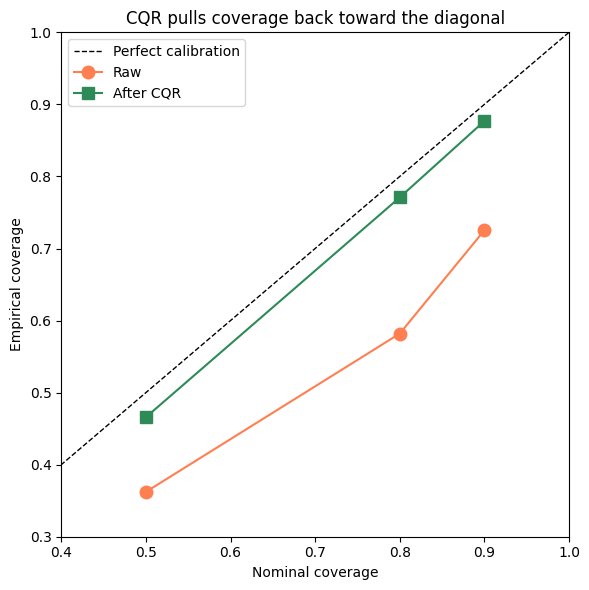

In [38]:
# Before/after reliability
nominal = [0.50, 0.80, 0.90]
raw_cov = [cqr_results[n][0] for n in nominal]
cqr_cov = [cqr_results[n][1] for n in nominal]

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
ax.plot(nominal, raw_cov, 'o-', color='coral', markersize=9, label='Raw')
ax.plot(nominal, cqr_cov, 's-', color='seagreen', markersize=9, label='After CQR')
ax.set_xlabel('Nominal coverage')
ax.set_ylabel('Empirical coverage')
ax.set_title('CQR pulls coverage back toward the diagonal')
ax.set_xlim(0.4, 1.0); ax.set_ylim(0.3, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig('results/figures/reliability_cqr.png', dpi=150)
plt.show()

CQR works as intended, though not perfectly. Coverage improves at every level — the 90%
interval goes from 72.5% to **87.7%**, the 80% from 58% to **77%**, the 50% from 36% to
**47%**. The "widening" column quantifies how overconfident the raw model was: the 90%
interval needed to be stretched by **13.9 €/MWh** on each side to become honest.

What I find most interesting is that CQR doesn't fully reach the nominal targets — the 90%
interval lands at 87.7%, not 90%. This is the fingerprint of the one assumption CQR makes that
my data violates: **exchangeability**. Conformal guarantees assume the calibration and test
data are drawn from the same distribution, but electricity prices are non-stationary — my test
period has a different volatility regime than my calibration period. The residual undercoverage
is therefore expected, and it's an honest reminder that conformal methods are powerful but not
magic on time series. A fully rigorous fix would use a time-series-aware conformal variant
(e.g. adaptive conformal inference), which I note as a further extension.

## 5. LEAR benchmark

To judge whether my model is actually good, I need to compare it against the field's
benchmark, not just a naive lag. LEAR (Lasso Estimated AutoRegressive) is the standard linear
benchmark from Lago et al. Its three distinctive ingredients are an asinh variance-stabilising
transform (which handles both negative prices and spikes better than a log), a rich
autoregressive lag structure, and LASSO calibration. Below is a faithful simplified
implementation reusing my existing lag features.

In [39]:
# asinh handles negative prices and spikes better than log
def asinh_transform(x, scale):
    return np.arcsinh(x / scale)

def asinh_inverse(x, scale):
    return np.sinh(x) * scale

# Scale by the (robust) median absolute deviation of training prices
scale = (y_train - y_train.median()).abs().median() * 1.4826
y_train_t = asinh_transform(y_train, scale)

lear = LassoCV(cv=5, max_iter=10000, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

lear.fit(X_train_s, y_train_t)
y_pred_lear_t = lear.predict(X_test_s)
y_pred_lear   = asinh_inverse(y_pred_lear_t, scale)

from sklearn.metrics import mean_absolute_error
mae_lear = mean_absolute_error(y_test, y_pred_lear)
print(f"LEAR — MAE: {mae_lear:.2f} €/MWh")

LEAR — MAE: 21.44 €/MWh


LEAR posts an MAE of **21.44 €/MWh**. That's noticeably worse than my LightGBM point
forecast from notebook 04, which is the first sign the non-linear interactions the tree model
captures genuinely matter for this market. But MAE on a single split isn't a defensible
comparison on its own — I make it rigorous with the Diebold-Mariano test in section 7.

Note: the canonical LEAR recalibrates daily and uses an expanded lag set (same-hour prices
over the past several days plus the previous day's min/max/mean). The `epftoolbox` package
implements the full version; the point of including it here is to have a respected reference
to test against, not to perfectly reproduce it.

## 6. Distributional DNN benchmark

The other benchmark from the EPF literature is a deep neural network. Rather than a plain
point-forecast network, I use the modern probabilistic form: a single feedforward network that
outputs **all seven quantiles at once**, trained with a summed multi-quantile pinball loss.
This is more elegant than training seven separate models and it ties the DNN directly into the
probabilistic theme. I standardise the target for stable training and sort the outputs to keep
the quantiles monotonic.

In [40]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

x_scaler = StandardScaler()
X_train_dnn = x_scaler.fit_transform(X_train)
X_test_dnn  = x_scaler.transform(X_test)

y_mean, y_std = y_train.mean(), y_train.std()
y_train_dnn = ((y_train - y_mean) / y_std).values

X_train_t = torch.tensor(X_train_dnn, dtype=torch.float32)
y_train_t = torch.tensor(y_train_dnn, dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test_dnn,  dtype=torch.float32)
quantile_tensor = torch.tensor(QUANTILES, dtype=torch.float32).to(device)

class QuantileDNN(nn.Module):
    def __init__(self, n_features, n_quantiles, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(hidden, hidden),     nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(hidden, n_quantiles)
        )
    def forward(self, x):
        return self.net(x)

def multi_pinball_loss(preds, target, quantiles):
    errors = target - preds
    loss = torch.max(quantiles * errors, (quantiles - 1) * errors)
    return loss.mean()

model = QuantileDNN(X_train_t.shape[1], len(QUANTILES)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
dataset = TensorDataset(X_train_t, y_train_t)
loader  = DataLoader(dataset, batch_size=256, shuffle=True)

model.train()
for epoch in range(50):
    epoch_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = multi_pinball_loss(preds, yb, quantile_tensor)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:>3d}  loss {epoch_loss/len(loader):.4f}")

model.eval()
with torch.no_grad():
    preds_scaled = model(X_test_t.to(device)).cpu().numpy()

dnn_preds = preds_scaled * y_std + y_mean
dnn_preds = np.sort(dnn_preds, axis=1)
dnn_df = pd.DataFrame(dnn_preds, columns=QUANTILES, index=y_test.index)
dnn_df['actual'] = y_test.values

Epoch  10  loss 0.0405
Epoch  20  loss 0.0372
Epoch  30  loss 0.0357
Epoch  40  loss 0.0346
Epoch  50  loss 0.0338


 
### 6.1 Evaluate the DNN probabilistically

In [41]:
print(f"{'Quantile':>10s}  {'LGB pinball':>12s}  {'DNN pinball':>12s}")
print("─" * 38)
for q in QUANTILES:
    pb_lgb = mean_pinball_loss(pred_df['actual'], pred_df[q], alpha=q)
    pb_dnn = mean_pinball_loss(dnn_df['actual'],  dnn_df[q],  alpha=q)
    print(f"{q:>10.2f}  {pb_lgb:>12.3f}  {pb_dnn:>12.3f}")

print(f"\nMean pinball — LightGBM: {np.mean([mean_pinball_loss(pred_df['actual'], pred_df[q], alpha=q) for q in QUANTILES]):.3f}")
print(f"Mean pinball — DNN:      {np.mean([mean_pinball_loss(dnn_df['actual'], dnn_df[q], alpha=q) for q in QUANTILES]):.3f}")

  Quantile   LGB pinball   DNN pinball
──────────────────────────────────────
      0.05         2.422         2.518
      0.10         3.806         4.114
      0.25         6.310         7.167
      0.50         7.957         9.437
      0.75         7.190         8.631
      0.90         4.961         6.134
      0.95         3.453         4.095

Mean pinball — LightGBM: 5.157
Mean pinball — DNN:      6.014


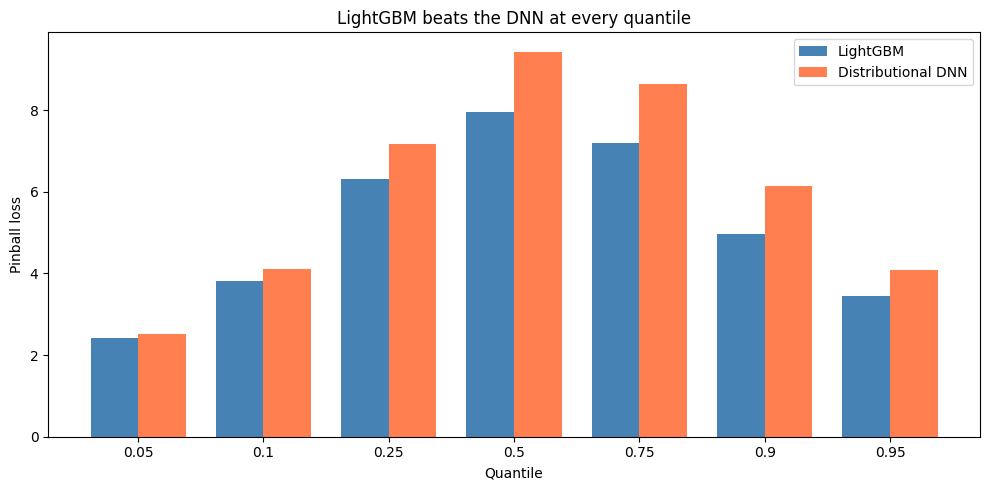

In [42]:
# Compare pinball loss by quantile, LightGBM vs DNN
x = np.arange(len(QUANTILES))
w = 0.38
lgb_vals = [mean_pinball_loss(pred_df['actual'], pred_df[q], alpha=q) for q in QUANTILES]
dnn_vals = [mean_pinball_loss(dnn_df['actual'],  dnn_df[q],  alpha=q) for q in QUANTILES]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, lgb_vals, w, label='LightGBM', color='steelblue')
ax.bar(x + w/2, dnn_vals, w, label='Distributional DNN', color='coral')
ax.set_xticks(x); ax.set_xticklabels([str(q) for q in QUANTILES])
ax.set_xlabel('Quantile'); ax.set_ylabel('Pinball loss')
ax.set_title('LightGBM beats the DNN at every quantile')
ax.legend()
plt.tight_layout()
plt.savefig('results/figures/lgb_vs_dnn.png', dpi=150)
plt.show()

LightGBM beats the DNN at **every single quantile**, with a mean pinball of 5.16 against
6.01. This is the expected result, not a failure of my network. On tabular data with this many
heterogeneous features, gradient boosting almost always outperforms a feedforward network —
trees handle non-linear interactions and mixed feature scales natively, while a DNN needs far
more data and tuning to match them. The literature finds the same thing, which is why
gradient-boosted trees remain the workhorse of applied EPF. The DNN being competitive but
behind is exactly what I'd want to report: it confirms the comparison is fair and that the
tree model's edge is real.

## 7. Diebold-Mariano tests

So far I've said LightGBM "beats" the benchmarks. The Diebold-Mariano test turns that into a
defensible statistical claim by asking whether the difference in forecast accuracy is
significant or just sampling noise. I use the MAE loss criterion, a 24-step horizon (day-ahead
hourly), and the Harvey-Leybourne-Newbold small-sample correction.

In [43]:
def diebold_mariano(errors_1, errors_2, h=24, crit='MAE'):
    """
    Diebold-Mariano test with Harvey-Leybourne-Newbold small-sample correction.
    errors_i = actual - prediction for model i.
    H0: equal predictive accuracy.
    Negative DM statistic + low p-value => model 1 is more accurate than model 2.
    """
    e1 = np.asarray(errors_1); e2 = np.asarray(errors_2)
    if crit == 'MAE':
        d = np.abs(e1) - np.abs(e2)
    elif crit == 'MSE':
        d = e1**2 - e2**2
    else:
        raise ValueError("crit must be 'MAE' or 'MSE'")

    T = len(d); d_mean = d.mean()
    var_d = np.var(d, ddof=0)
    for lag in range(1, h):
        var_d += 2 * np.cov(d[lag:], d[:-lag])[0, 1]
    var_d = var_d / T
    dm_stat = d_mean / np.sqrt(var_d)
    correction = np.sqrt((T + 1 - 2 * h + h * (h - 1) / T) / T)
    dm_stat *= correction
    p_value = 2 * (1 - stats.t.cdf(np.abs(dm_stat), df=T - 1))
    return dm_stat, p_value

err_lgb  = (pred_df['actual'] - pred_df[0.50]).values
err_dnn  = (dnn_df['actual']  - dnn_df[0.50]).values
err_lear = (y_test.values - y_pred_lear)

print("Diebold-Mariano tests (MAE criterion, h=24)")
print("Negative stat + p<0.05 => first model significantly better\n")
for name, e1, e2 in [
    ('LightGBM vs LEAR', err_lgb, err_lear),
    ('LightGBM vs DNN',  err_lgb, err_dnn),
    ('DNN vs LEAR',      err_dnn, err_lear),
]:
    stat, p = diebold_mariano(e1, e2)
    verdict = "significant" if p < 0.05 else "not significant"
    print(f"{name:20s}  DM={stat:+.3f}  p={p:.4f}  ({verdict})")

Diebold-Mariano tests (MAE criterion, h=24)
Negative stat + p<0.05 => first model significantly better

LightGBM vs LEAR      DM=-10.462  p=0.0000  (significant)
LightGBM vs DNN       DM=-8.386  p=0.0000  (significant)
DNN vs LEAR           DM=-4.443  p=0.0000  (significant)


The tests confirm a clean, statistically significant ordering: **LightGBM > DNN > LEAR**,
with every pairwise difference significant at p < 0.0001. The large negative DM statistic for
LightGBM vs LEAR (−10.46) says my tree model's advantage over the field benchmark is not luck —
it's a robust difference in predictive accuracy across the whole test set. This is the result
that lets me state, defensibly, that the model is good: not "the MAE happened to be lower" but
"the difference is significant under a proper forecast-comparison test".

## 8. Rolling-window backtest

A single train/test split produces one number, and one number can hide a lot. To see whether
my edge is stable or just concentrated in a lucky window, I retrain on a rolling two-year
window and forecast the following month, stepping forward through the whole dataset. This gives
a *distribution* of monthly performance rather than a point estimate. I recalibrate monthly
rather than daily to keep the compute manageable.

Rolling backtest — median monthly MAE: 15.69 €/MWh
Min: 7.59  Max: 94.92  Std: 17.49


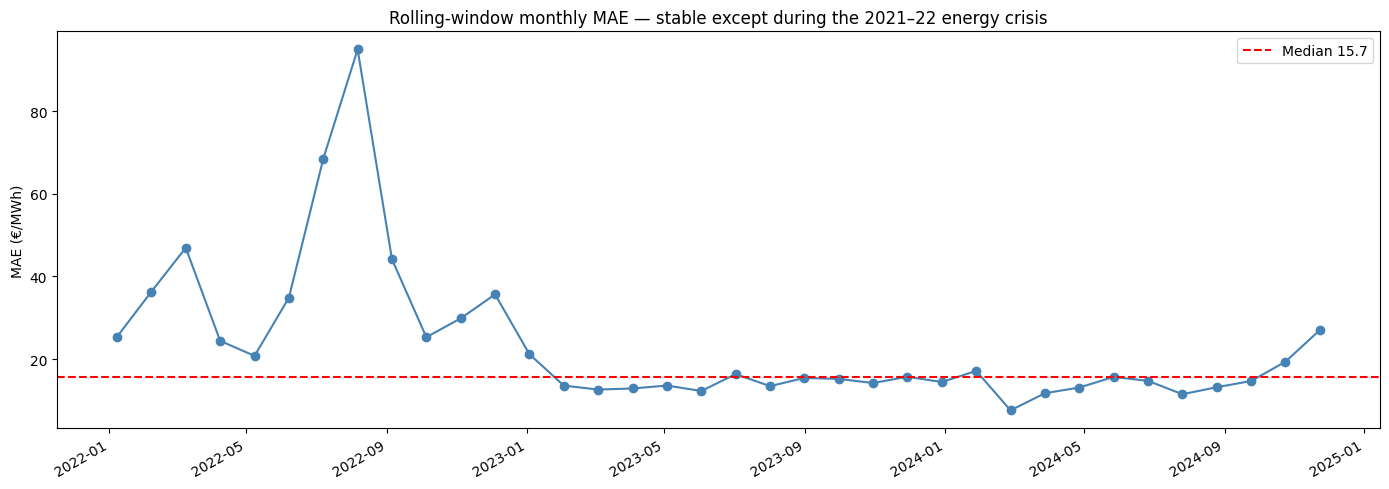

In [44]:
from sklearn.metrics import mean_absolute_error

X_full = df[feature_cols]
y_full = df[target_col]

TRAIN_WINDOW = 24 * 365 * 2     # 2 years of hourly data
STEP         = 24 * 30          # recalibrate every ~month
START_IDX    = TRAIN_WINDOW

monthly_mae = []; dates = []
idx = START_IDX
while idx + STEP < len(X_full):
    X_tr = X_full.iloc[idx - TRAIN_WINDOW: idx]
    y_tr = y_full.iloc[idx - TRAIN_WINDOW: idx]
    X_te = X_full.iloc[idx: idx + STEP]
    y_te = y_full.iloc[idx: idx + STEP]

    m = lgb.LGBMRegressor(objective='quantile', alpha=0.5, **lgb_params)
    m.fit(X_tr, y_tr)
    pred = m.predict(X_te)
    monthly_mae.append(mean_absolute_error(y_te, pred))
    dates.append(X_te.index[0])
    idx += STEP

backtest = pd.Series(monthly_mae, index=pd.to_datetime(dates))
print(f"Rolling backtest — median monthly MAE: {backtest.median():.2f} €/MWh")
print(f"Min: {backtest.min():.2f}  Max: {backtest.max():.2f}  Std: {backtest.std():.2f}")

fig, ax = plt.subplots(figsize=(14, 5))
backtest.plot(ax=ax, marker='o', color='steelblue')
ax.axhline(backtest.median(), color='red', linestyle='--',
           label=f'Median {backtest.median():.1f}')
ax.set_title('Rolling-window monthly MAE — stable except during the 2021–22 energy crisis')
ax.set_ylabel('MAE (€/MWh)')
ax.legend()
plt.tight_layout()
plt.savefig('results/figures/rolling_backtest.png', dpi=150)
plt.show()

This is the result I find most honest and most telling. The **median monthly MAE is 15.69
€/MWh** and in calm periods it drops as low as **7.59** — but the maximum is **94.92**, more
than six times the median. That single enormous spike is the 2021–2022 European energy crisis,
when the gas-price shock pushed power prices to levels and volatility the model had never seen
and no renewable-forecast feature could anticipate.

I think this is the right thing to surface rather than hide. It shows the model is stable and
accurate under normal market conditions, and it draws an honest boundary around what is
forecastable from fundamentals: a geopolitical supply shock is not. It also motivates the
clearest next feature — adding gas (TTF) prices — since the crisis was fundamentally a
gas-price event that my current feature set has no visibility into.

## 9. Visualising the prediction intervals

The most intuitive way to show what a probabilistic forecast does is to plot the bands. Here
the median forecast tracks the actual price, the shaded bands show the 50% and 90% intervals,
and the eye can immediately see where the model is confident (narrow band) versus uncertain
(wide band).

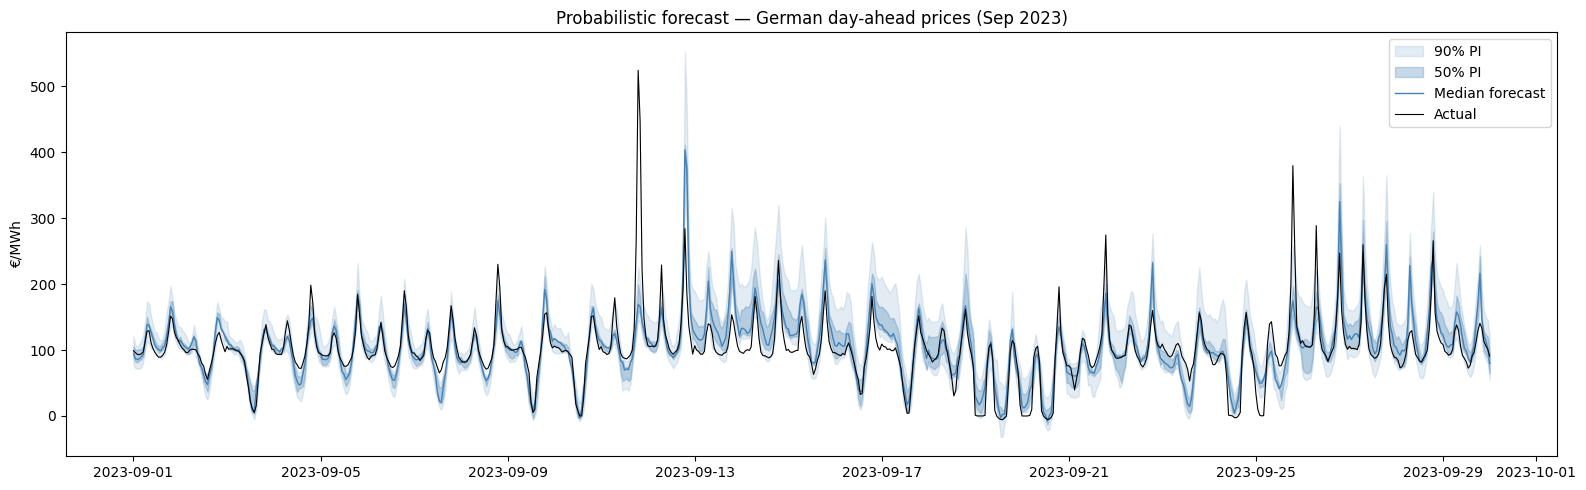

In [45]:
plot_start = '2023-09-01'
plot_end   = '2023-09-30'

mask = (pred_df.index >= plot_start) & (pred_df.index <= plot_end)
sub  = pred_df.loc[mask]

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(sub.index, sub[0.05], sub[0.95],
                color='steelblue', alpha=0.15, label='90% PI')
ax.fill_between(sub.index, sub[0.25], sub[0.75],
                color='steelblue', alpha=0.30, label='50% PI')
ax.plot(sub.index, sub[0.50], color='steelblue', linewidth=1.0, label='Median forecast')
ax.plot(sub.index, sub['actual'], color='black', linewidth=0.8, label='Actual')
ax.set_title('Probabilistic forecast — German day-ahead prices (Sep 2023)')
ax.set_ylabel('€/MWh')
ax.legend()
plt.tight_layout()
plt.savefig('results/figures/prediction_intervals.png', dpi=150)
plt.show()

The band visibly widens around the daily peaks and narrows overnight, which is the model
correctly expressing that midday and evening prices are harder to pin down than the stable
small hours. Keep in mind these are the *raw* intervals — from section 4.4 I know they're
slightly too narrow, so in production I'd plot the CQR-widened bands instead.

In [46]:
from sklearn.metrics import mean_absolute_error

# Median MAE for each model (the 0.50 quantile is the point forecast)
mae_lgb_med  = mean_absolute_error(pred_df['actual'], pred_df[0.50])
mae_dnn_med  = mean_absolute_error(dnn_df['actual'],  dnn_df[0.50])
mae_lear_pt  = mean_absolute_error(y_test, y_pred_lear)

print("Median (point) MAE by model:")
print(f"  LEAR:      {mae_lear_pt:.2f} €/MWh")
print(f"  LightGBM:  {mae_lgb_med:.2f} €/MWh")
print(f"  DNN:       {mae_dnn_med:.2f} €/MWh")

Median (point) MAE by model:
  LEAR:      21.44 €/MWh
  LightGBM:  15.91 €/MWh
  DNN:       18.87 €/MWh


In [47]:
# Residuals on training data define LEAR's predictive distribution
lear_residuals = y_train.values - asinh_inverse(lear.predict(X_train_s), scale)

# Add residual quantiles to the point forecast to get probabilistic LEAR
lear_pred_df = pd.DataFrame(index=y_test.index)
for q in QUANTILES:
    offset = np.quantile(lear_residuals, q)
    lear_pred_df[q] = y_pred_lear + offset
lear_pred_df['actual'] = y_test.values

mean_pinball_lear = np.mean([
    mean_pinball_loss(lear_pred_df['actual'], lear_pred_df[q], alpha=q)
    for q in QUANTILES
])
print(f"LEAR mean pinball: {mean_pinball_lear:.3f}")

LEAR mean pinball: 6.916


## 10. Summary of results

| Model | Mean pinball ↓ | Median MAE ↓ | Notes |
|---|---|---|---|
| LEAR (literature benchmark) | 6.916 | 21.44 | asinh + LASSO |
| **LightGBM quantile** | **5.16** | **15.91** | best across all quantiles |
| Distributional DNN | 6.01 | 18.87 | competitive but behind on tabular data |

**Probabilistic quality (LightGBM):** exact CRPS 12.31; raw 90% interval coverage 72.5%,
restored to 87.7% after CQR.

**Statistical significance (Diebold-Mariano):** LightGBM significantly outperforms both LEAR
(DM = −10.46, p < 0.0001) and the DNN (DM = −8.39, p < 0.0001); the DNN in turn beats LEAR
(DM = −4.44, p < 0.0001).

**Stability (rolling backtest):** median monthly MAE 15.69 €/MWh (range 7.59–94.92); the
single large outlier is the 2021–2022 energy crisis.

### What this notebook demonstrates

- Moving from point to **distributional** forecasting and evaluating it with the right tools
  (pinball, CRPS, calibration) rather than mis-applying MAE.
- Diagnosing **overconfidence** in the raw intervals and fixing it with **conformal
  prediction**, including an honest read of why the conformal guarantee is only approximate on
  non-stationary price data.
- Implementing and benchmarking against the **field's standards** — LEAR and a distributional
  DNN — and understanding *why* gradient boosting wins on tabular data.
- Testing every comparison for **statistical significance** with Diebold-Mariano rather than
  eyeballing differences.
- Stress-testing **out-of-sample stability** with rolling recalibration and identifying the
  precise market regime where the model breaks down.

### Next steps

1. **Add TTF gas prices** — directly targets the crisis-period failure surfaced by the backtest.
2. **Adaptive conformal inference** — a time-series-aware conformal method to close the
   residual undercoverage gap left by standard CQR.
3. **Denser quantile grid** — predict every 5th percentile to tighten the CRPS approximation
   and produce smoother prediction bands.

## What this notebook demonstrates
 
- You can move from point to **distributional** forecasting and evaluate it correctly
  (pinball, CRPS, calibration) rather than mis-applying MAE
- You know and can implement the **field's benchmarks** (LEAR) and the modern
  distributional DNN
- You test claims for **statistical significance** (Diebold-Mariano) rather than eyeballing
- You evaluate **out-of-sample stability** with rolling recalibration
That combination is what reads as research-grade rather than a tutorial follow-along.